In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("DQ_full.csv")
df.head()

,Index,Zeit,Langenanderung,Temperatur
0,1,0.000000,0.000000,19.255493
1,2,1.666758,-0.227827,19.142557
2,3,3.333537,-0.225082,18.990231
3,4,5.000242,-0.225082,19.795895
4,5,6.667147,-0.230572,19.392607


In [3]:
time=df.loc[:,"Zeit"]
length=df.loc[:,"Langenanderung"]
temperature=df.loc[:,"Temperatur"]

In [4]:
print(len(time))
print(len(length))
print(len(temperature))

1295
1295
1295


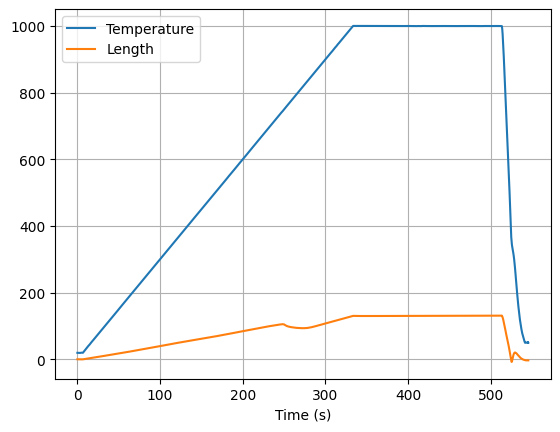

In [5]:
plt.plot(time, temperature, label='Temperature')
plt.plot(time, length, label='Length')
plt.xlabel('Time (s)')
plt.legend()
plt.legend()
plt.grid(True)

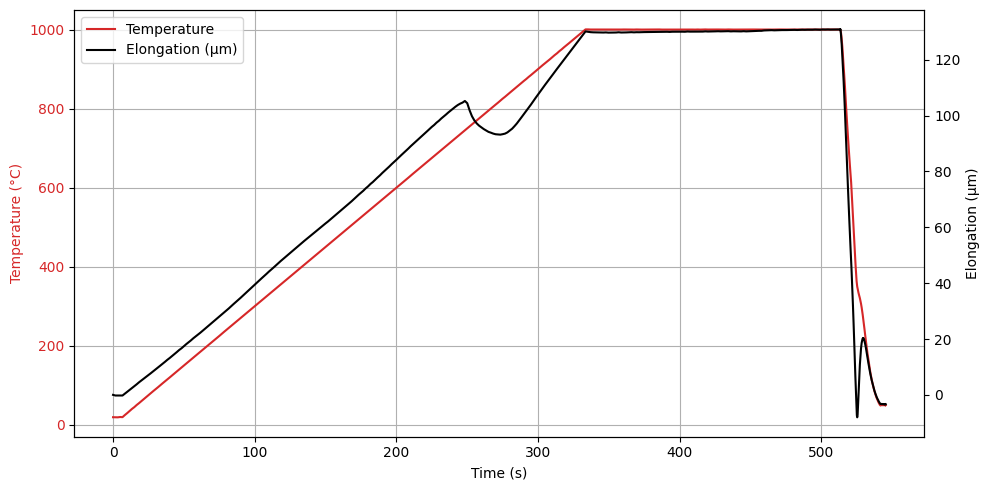

In [17]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots()

# Plot temperature on the left axis
ax1.plot(time, temperature, color='tab:red', label='Temperature')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Temperature (°C)', color='tab:red')
ax1.tick_params(axis='y', labelcolor='tab:red')

# Create second y-axis for length
ax2 = ax1.twinx()
ax2.plot(time, length, color='black', label='Elongation (µm)')
ax2.set_ylabel('Elongation (µm)', color='black')
ax2.tick_params(axis='y', labelcolor='black')

# Title, grid, and legend
# plt.title('Temperature and Elongation over Time')
ax1.grid(True)

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')

fig.set_size_inches(10, 5, forward=True)
plt.tight_layout()
plt.show()


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

time = df["Zeit"].values
temp = df["Temperatur"].values
dl = df["Langenanderung"].values

# smooth dilatation
dl_smooth = savgol_filter(dl, window_length=51, polyorder=3)

# derivative
ddl_dt = np.gradient(dl_smooth, time)


In [8]:
threshold = 0.02 * np.max(np.abs(ddl_dt))

mask = np.abs(ddl_dt) > threshold

t_start = time[mask][0]
t_finish = time[mask][-1]
T_iso = np.mean(temp[mask])

print("Start:", t_start)
print("Finish:", t_finish)
print("Temperature:", T_iso)


Start: 18.33428574
Finish: 541.4006958
Temperature: 515.1404251210828


In [9]:
results = []
results.append({
    "T": T_iso,
    "t_start": t_start,
    "t_finish": t_finish
})


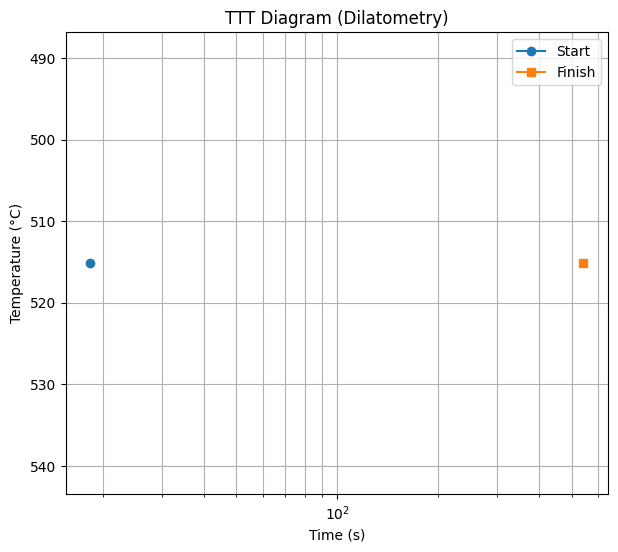

In [10]:
res = pd.DataFrame(results)

plt.figure(figsize=(7,6))
plt.semilogx(res["t_start"], res["T"], 'o-', label="Start")
plt.semilogx(res["t_finish"], res["T"], 's-', label="Finish")

plt.gca().invert_yaxis()
plt.xlabel("Time (s)")
plt.ylabel("Temperature (°C)")
plt.title("TTT Diagram (Dilatometry)")
plt.legend()
plt.grid(True, which="both")
plt.show()

